In [ ]:
# Install dependencies (only needed on Google Colab or fresh environments)
%pip install vima-spatial adjustText -q

# VIMA quick start

**VIMA** (variational inference-based microniche analysis) finds regions of tissue whose abundance differs between cases and controls in multi-sample spatial molecular data — with no cell segmentation or clustering required.

The workflow has four steps:

1. **Model training** - train `vima`'s ensemble of variational autoencoders to learn how to represent the tissue in your dataset.
2. **Fingerprint generation** — use the trained autoencoders to turn small tissue patches into numerical "fingerprints" that capture their biology.
3. **Association testing** — find *microniches* (groups of patches with similar fingerprints) whose abundance tracks case/control status.
4. **Interpretation** — inspect the associated microniches to see what is biologically different.

Each step has a core function call

```python
_      = vima.fit(models, patches, dense_patches)                   # 1. train
ds     = vima.latentreps(model, dense_patches)                      # 2. fingerprint
p, D   = vima.association(ds, samplemeta.case, 'sid')               # 3. associate
enrich = vima.test_features(D.obsm['abundances'], D.obs.sig_pos)    # 4. interpret
```

This demo runs on a toy 10-sample brain spatial transcriptomics dataset that we've modified by spiking in a case-control signal. Step 1 requires the raw data and a GPU, so we download precomputed fingerprints and start from step 3. To download the raw data and regenerate the fingerprints yourself, see the [appendix](#appendix-reproducing-the-fingerprints-from-raw-data).

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import glob, os, vima

np.random.seed(0)
vima.settings.verbosity = 'minimal'

## Download the data

We download the sample metadata (`samplemeta.tsv`, with case/control labels), a cell-segmentation table (`cells.tsv`, used only for interpretation), and the precomputed patch fingerprints (`fingerprints.h5ad`). This is about 300MB.

In [ ]:
vima.download_toy_metadata_and_fingerprints("./data/ST")

samplemeta.tsv:   0%|                                                                                         …

cells.tsv:   0%|                                                                                              …

fingerprints.h5ad:   0%|                                                                                      …

## Association testing

Load the precomputed fingerprints and the sample metadata, then run a single permutation test that scores every microniche for association with case status. Significant microniches are labeled for use below.

compute MAMs:   0%|                                                                                           …

P = 0.007899210078992101


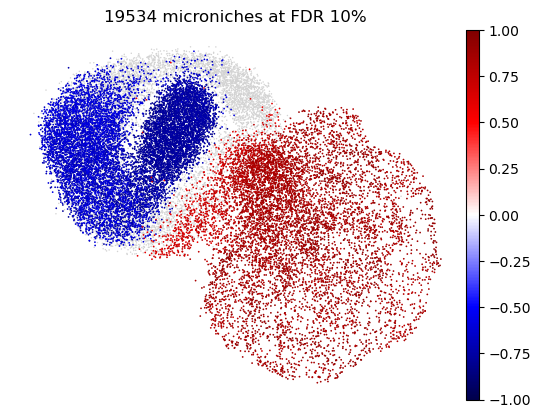

In [3]:
# read in fingerprints and sample metadata
ds = vima.Fingerprints.read_h5ad('data/ST/fingerprints.h5ad')
samplemeta = pd.read_csv('data/ST/samplemeta.tsv', sep='\t').set_index('sid', drop=True)

# association test
p, D = vima.association(ds, samplemeta.case, 'sid')
vima.v.plot_association(D)

# label significant results
D.obs['sig_pos'] = (D.obs.mncoef > 0) & (D.obs.mncoef_fdr <= 0.1)
D.obs['sig_neg'] = (D.obs.mncoef < 0) & (D.obs.mncoef_fdr <= 0.1)
D.write('data/ST/association_results.h5ad')

We now plot, in space, the strength of association between each patch and case status. Red = positive association, blue = negative association.

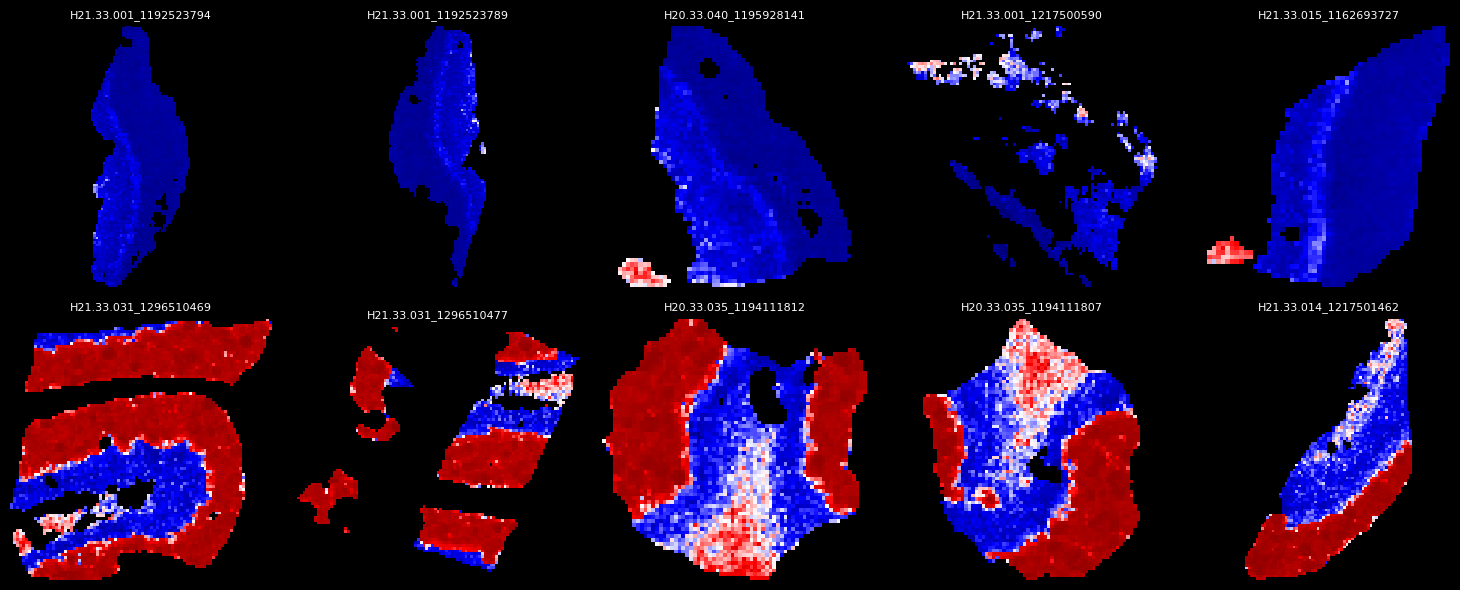

In [4]:
vima.v.spatialplot(D.obs, D.obs.mncoef,
                    sids=samplemeta.sort_values(by='case').index, # sort samples by case status
                    cmap='seismic', vmin=-1, vmax=1);

## Interpretation

The case-control signal we spiked in is that within cortical layers 2/3 the case tissue shows sharply elevated expression of a family of **SECRET genes**. The plots below show that `vima` found this difference withing requiring cell types or hard clustering steps. The [Detailed interpretation](#detailed-interpretation) section retraces exactly how we got to this interpretation in an unbiased way.

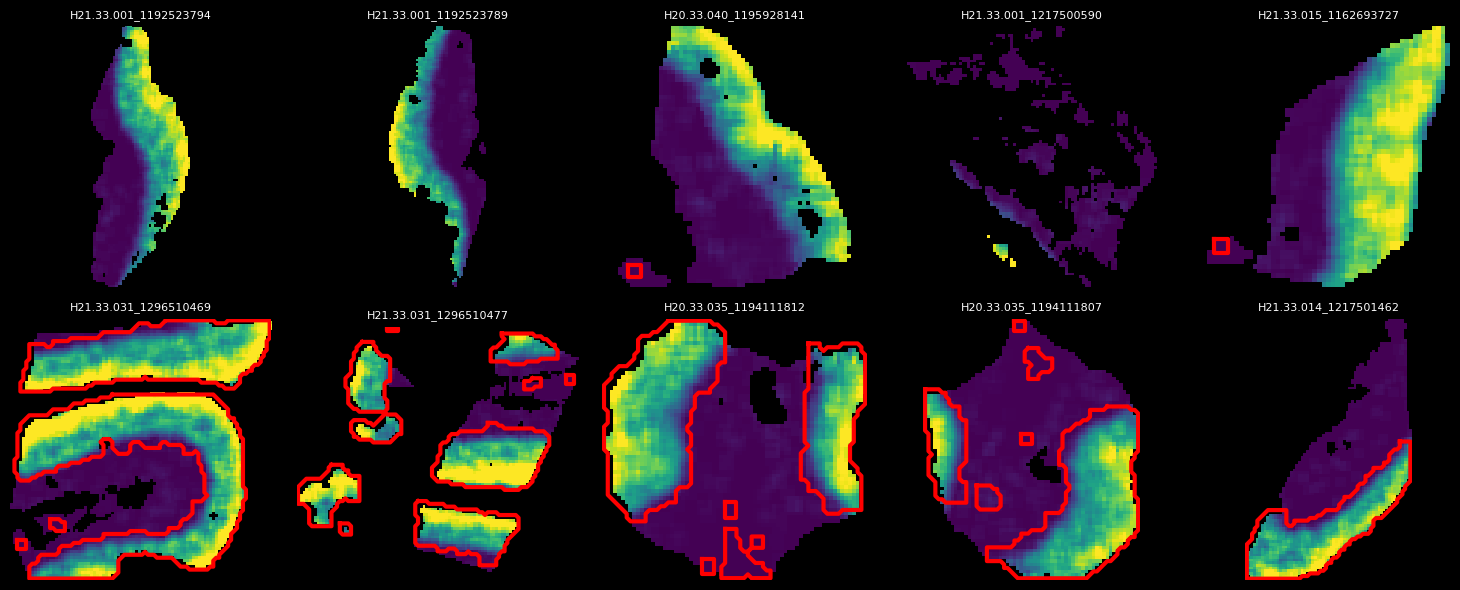

In [5]:
# visualize case-associated patches vs L2/3-rich patches in space
vima.v.spatialplot(D.obs, D.obsm['abundances']['L2/3 IT'],
                    sids=samplemeta.sort_values(by='case').index, # sort samples by case status
                    cmap='viridis',
                    show=False)
vima.v.annotate_spatialplot(D.obs, D.obs.sig_pos, 'red', show=False);

^ Spatial abundance of L2/3 IT cells with case-associated patches outlined in red
(control samples on top, case samples on bottom).

We see that the case-associated patches (outlined in red) are mostly concentrated in the L2/3-rich  
areas of the tissue in case samples, suggesting that vima is picking up on changes in these layers.

Let's now visualize composite images of case-associated and control-associated patches for the two most differentially expressed genes, SECRET11 and SECRET20.


Adding 2 markers: |                                                                                           …

Reading samples:   0%|                                                                                        …

Reading samples:   0%|                                                                                        …

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Reading samples:   0%|                                                                                        …

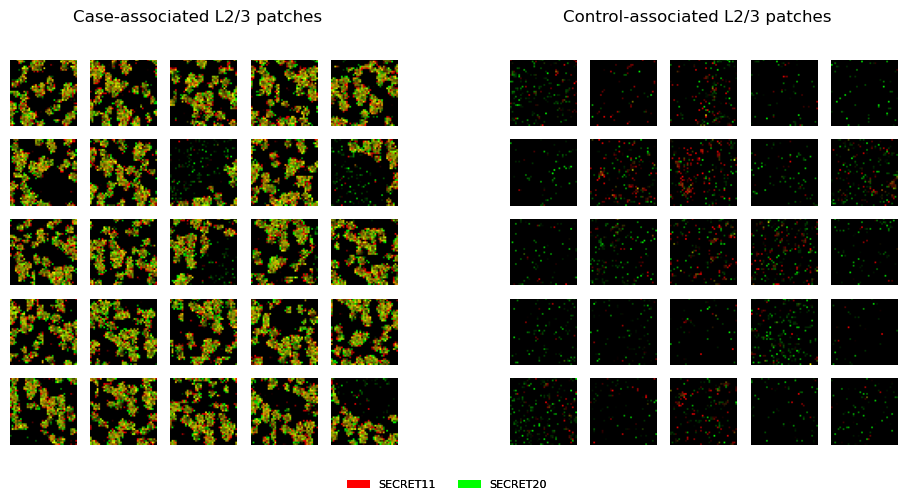

In [6]:
fig = plt.figure(figsize=(10, 5))
sf_pos, sf_neg = fig.subfigures(1, 2)
sf_pos.suptitle('Case-associated L2/3 patches')
sf_neg.suptitle('Control-associated L2/3 patches')
vima.v.show_patches_composite(
    patchmeta = D.obs[D.obs.sig_pos],
    markers   = ['SECRET11','SECRET20'],
    directory = 'data/ST/10u/normalized',
    features = D.X[D.obs.sig_pos],
    nx=5, ny=5, subfig=sf_pos, show=False
)
vima.v.show_patches_composite(
    patchmeta = D.obs[D.obs.sig_neg],
    markers   = ['SECRET11','SECRET20'],
    directory = 'data/ST/10u/normalized',
    features = D.X[D.obs.sig_neg],
    nx=5, ny=5, subfig=sf_neg);

## Detailed interpretation

This section retraces the analysis behind the conclusions above: which cell types the associated microniches are enriched for, which genes drive the case/control difference within layer 2/3, and confirmation of that signal both in space and in the raw patch images.

In [7]:
# compute enrichments for all cell types between case-associated patches and rest
# we find that the case-associated patches are rich in L2/3 IT neurons and VIP interneurons,
# suggesting that they are concentrated in cortical layers 2 and 3
ct_enrichments = vima.test_features(D.obsm['abundances'],
              D.obs.sig_pos, unit_of_analysis=D.obs.sid)
sig_ct_enrichments = ct_enrichments[ct_enrichments.pvals_adj <= 0.1].sort_values(by='diff_median', ascending=False)
print('Most enriched cell types are:', sig_ct_enrichments.iloc[0].name, 'and', sig_ct_enrichments.iloc[1].name,
      f'\nwith log2fc\'s of {sig_ct_enrichments.iloc[0].log2fc:.2f} and',
      f'{sig_ct_enrichments.iloc[1].log2fc:.2f} respectively,'
      f'\nand adjusted P-values of {sig_ct_enrichments.iloc[0].pvals_adj:.3f} and {sig_ct_enrichments.iloc[1].pvals_adj:.3f}', 'respectively.')

Most enriched cell types are: L2/3 IT and Vip 
with log2fc's of 5.22 and 2.75 respectively,
and adjusted P-values of 0.010 and 0.010 respectively.


Let's verify the layer 2/3 signal by seeing which cell types are present in the case-associated patches vs other patches.

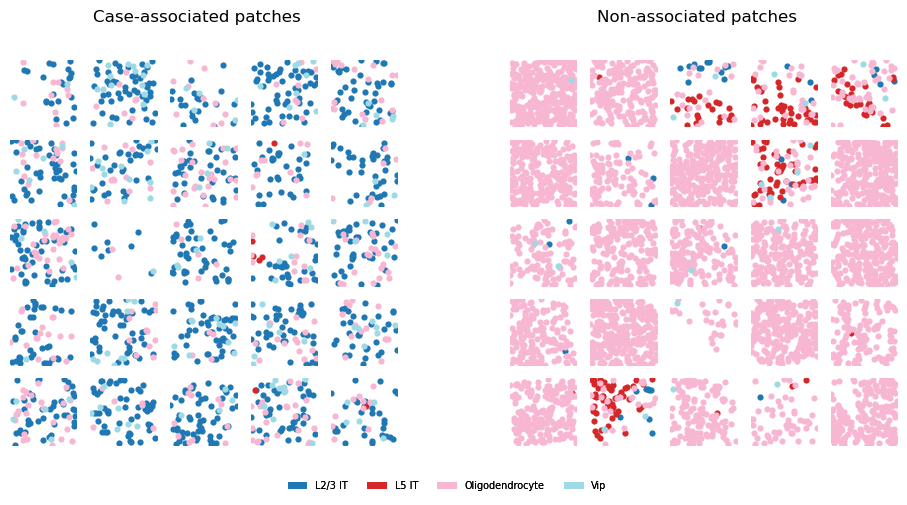

In [8]:
# visualize example case- and non-associated patches using the segmented cells
cells = pd.read_csv('data/ST/cells.tsv', sep='\t')
types_to_show = list(sig_ct_enrichments.index[:2]) + list(sig_ct_enrichments.index[-2:])

fig = plt.figure(figsize=(10, 5))
sf_pos, sf_neg = fig.subfigures(1, 2)
sf_pos.suptitle('Case-associated patches')
sf_neg.suptitle('Non-associated patches')
vima.v.show_patches_cells(D.obs[D.obs.mncoef > 0.8], cells,
                          include_only=types_to_show, # show only the top 5 enriched cell types for clarity
                          x_col='x', y_col='y', celltype_col='subclass_name',
                          pixelsize_microns=10, s=20, subfig=sf_pos, show=False)
vima.v.show_patches_cells(D.obs[D.obs.mncoef.abs() <= 0.2], cells,
                          include_only=types_to_show, # show only the top 5 enriched cell types for clarity
                          x_col='x', y_col='y', celltype_col='subclass_name',
                          pixelsize_microns=10, s=20, subfig=sf_neg);

We can also verify this signal quantitatively by visualizing the abundance of layer 2/3 IT cells in case-associated vs control-associated patches

Comparison of cell type abundances between case-associated and control-associated patches:


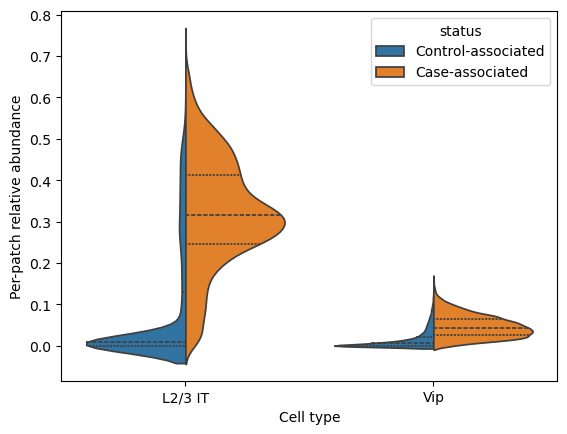

In [9]:
# visualize abundance differences between case-associated patches and rest, for top 2 cell types
print('Comparison of cell type abundances between case-associated and control-associated patches:')
vima.v.plot_features(D.obsm['abundances'],
                     D.obs.sig_pos,
                     n_top=2, n_bottom=0,
                     markers=sig_ct_enrichments.index,
                     labels=['Case-associated', 'Control-associated'],
                     show=False
                     )
plt.ylabel('Per-patch relative abundance')
plt.xlabel('Cell type')
plt.show()

Now - what is it about the layer 2/3 patches in the case samples that makes vima pick them up? Let's find out by comparing expression of all genes between case-associated L2/3 IT-rich patches and control-associated L2/3 IT-rich patches

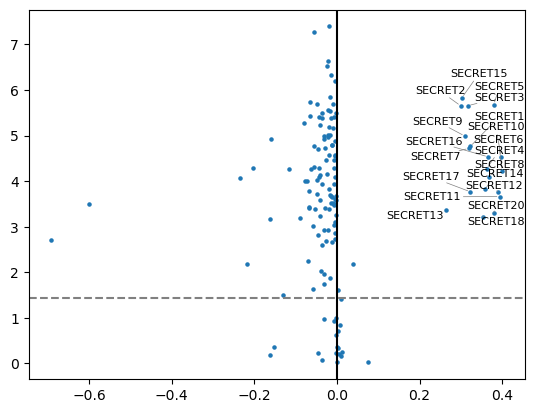

In [10]:
l23 = D.obsm['abundances']['L2/3 IT'] > 0.05
l23_sig_pos = D.obs.sig_pos & l23
l23_sig_neg = D.obs.sig_neg & l23
ge_enrichments = vima.test_features(D.obsm['expr'],
              l23_sig_pos, l23_sig_neg, unit_of_analysis=D.obs.sid,
              Ttest=True # here we use a T-test instead of the default permutation test
                         # in order to demonstrate this feature, which is appropriate for smaller
                         # datasets where permutation tests may not be well-powered.
                         # In practice in this example it will also work to set Ttest=False
                         # but the P-values will just be less impressive
              )
sig_ge_enrichments = ge_enrichments[ge_enrichments.pvals_adj <= 0.05].sort_values(by='diff_median', ascending=False)

# make volcano plot
from adjustText import adjust_text
plt.scatter(ge_enrichments.diff_median, -np.log10(ge_enrichments.pvals), s=5)
to_label = ge_enrichments[ge_enrichments.diff_median > 0.2]
texts = [plt.text(row.diff_median, -np.log10(row['pvals']), idx, fontsize=8)
         for idx, row in to_label.iterrows()]
adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))
plt.axhline(-np.log10(sig_ge_enrichments.pvals.max()*0.95), c='gray', linestyle='--')
plt.axvline(x=0, c='black')
plt.show()

^ Aha - Layer 2/3 in the case samples has elevated expression of these SECRET genes!

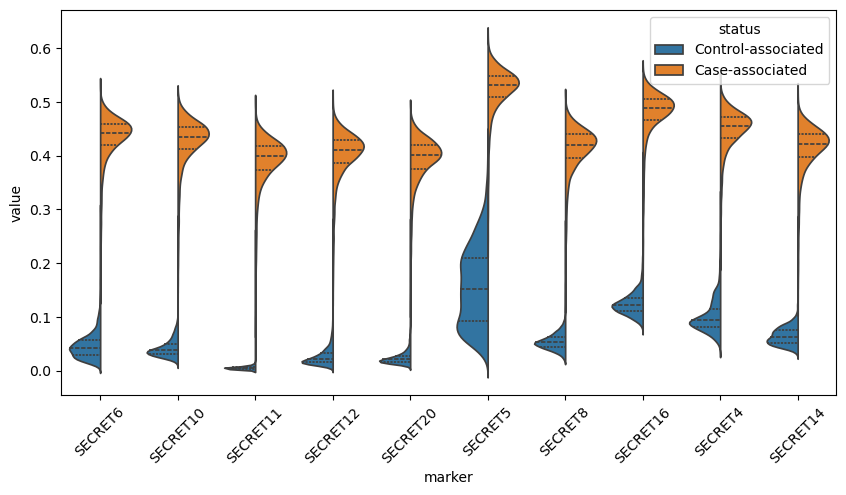

In [11]:
# Look at distribution of expression of top SECRET genes in
# case-associated L2/3 patches vs control-associated of L2/3 patches
plt.figure(figsize=(10, 5))
vima.v.plot_features(D.obsm['expr'],
                     l23_sig_pos,
                     l23_sig_neg,
                     n_top=10, n_bottom=0,
                     markers=sig_ge_enrichments.index,
                     labels=['Case-associated', 'Control-associated'],
                     show=False
                     )
plt.xticks(rotation=45)
plt.show()

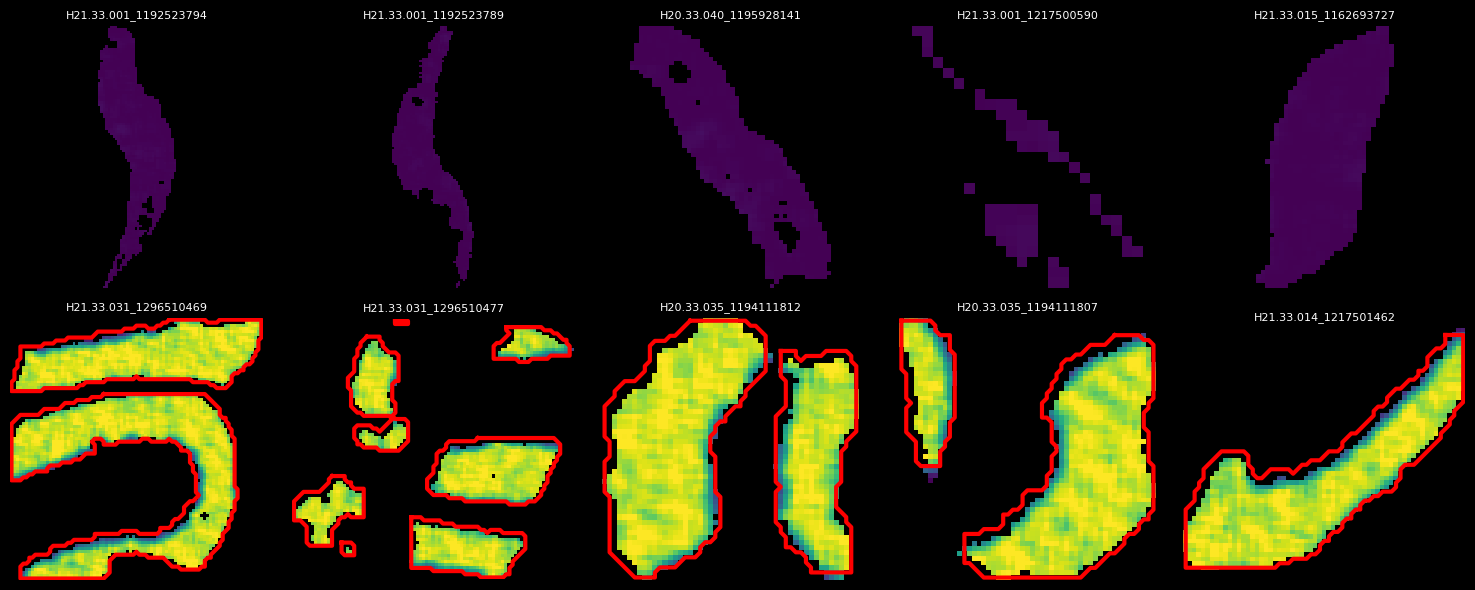

In [12]:
# let confirm this another way: by visualizing the distribution of expression
# of SECRET11 in space, restricting just to layer 2/3 of each sample
vima.v.spatialplot(D.obs[l23], D.obsm['expr'][l23]['SECRET11'],
                               cmap='viridis', sids=samplemeta.sort_values(by='case').index,
                               show=False)
vima.v.annotate_spatialplot(D.obs[l23], D.obs[l23].sig_pos, 'red');

## Appendix: reproducing the fingerprints from raw data

Everything above starts from `fingerprints.h5ad`. This appendix regenerates that file from the raw transcript tables — it rasterizes each sample into pixels, compresses the gene panel into meta-markers, batch-corrects across samples with Harmony, trains the VAE, and writes out the fingerprints. It needs the larger raw-data archive (~450 MB per sample) and a GPU, and takes considerably longer than the rest of the demo.

In [ ]:
# Download the raw transcript files (~450MB per sample; this can take a while)
vima.download_toy_rawdata("./data/ST/raw")

### Preprocess: rasterize, reduce to meta-markers, and harmonize

In [3]:
resolution = 10 #microns per pixel
nmetamarkers = 10 # desired number of meta-markers
transcriptfiles = glob.glob(f'data/ST/raw/*.parquet')
outdir = f'data/ST/{resolution}u'

# Define a function that reads in the raw transcript data for one sample and
# returns a tuple of (sample_id, dataframe)
# Note: blank probes and low-quality genes/transcripts should already be removed before this step
def load(path):
    sid = os.path.basename(path).replace('.parquet', '')
    data = pd.read_parquet(path) # can replace with read_csv as appopriate, but parquet is faster
    return sid, data

In [4]:
# load transcript files and rasterize into counts per pixel
vima.pp.st.prepare_merfish(load=load,
                           filepaths=transcriptfiles,
                           x_col='global_x',
                           y_col='global_y',
                           gene_col='gene',
                           outdir=outdir,
                           pixel_size=resolution)

# convert markers to meta-markers
repname = f'metamarkers_{nmetamarkers}'
allpixels_pca, pc_loadings = vima.pp.pca_pixels(outdir, repname, nmetamarkers=nmetamarkers)

# harmonize the meta-markers and write the results
harmpixels = vima.pp.harmonize(allpixels_pca)
vima.pp.write_harmonized(outdir, repname, harmpixels)

median #transcripts:   0%|                                                                                    …

HVGs & moments:   0%|                                                                                         …

rasterize & normalize:   0%|                                                                                  …

creating metapixels:   0%|                                                                                    …

pixels -> PCA space:   0%|                                                                                    …

write harmonized samples:   0%|                                                                               …

### Train the VAE and write the fingerprints

In [5]:
import torch
device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
torch.set_default_device(device)

In [6]:
# read in samples
samples = vima.read_samples(f'data/ST/10u/metamarkers_10/*.nc')

# choose initial set patches to train on and a smaller set of denser patches to refine training on
P = vima.PatchCollection(samples)
Pdense = P.refined(max_frac_empty=0.5)

read samples:   0%|                                                                                           …

choose patches:   0%|                                                                                         …

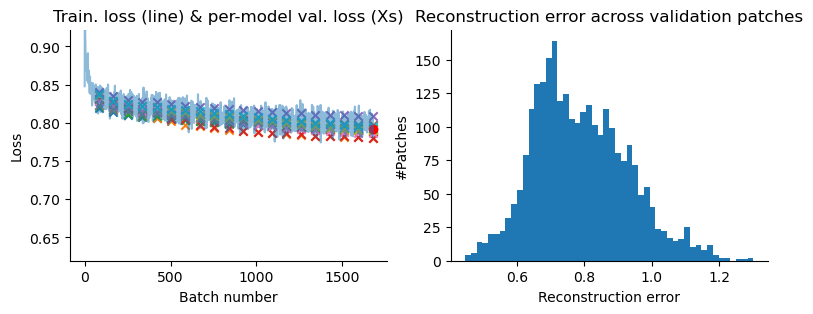

End of epoch 20
Avg. val. loss: 0.7920428693294526
Time elapsed this epoch: 189.69 sec
Total time elapsed: 3825.18 sec
Per-channel MSE (% of variance): 0.42 (42%), 0.64 (64%), 0.89 (89%), 0.84 (84%), 0.82 (82%), 0.75 (75%), 0.84 (84%), 0.89 (89%), 0.92 (92%), 0.88 (88%)
Best val. losses so far: 0.79, 0.78, 0.79, 0.78, 0.81, 0.8, 0.79, 0.8, 0.79, 0.8
Best epoch so far: 20, 20, 20, 20, 20, 20, 20, 20, 20, 20



In [7]:
# train the model and save results
models = vima.models.cVAE(P.nmarkers, P.covariate_sizes)
log_all, log_dense = vima.fit(models, P, Pdense)
torch.save(models.state_dict(), f'data/ST/weights.pt')

In [7]:
# read in model weights and create patch fingerprints
models = vima.models.cVAE(P.nmarkers, P.covariate_sizes, weights='data/ST/weights.pt')
ds = vima.latentreps(models, Pdense)

# add in patch-level metadata like cell type counts and avg expression, for downstream interpretation
cells = pd.read_csv('data/ST/cells.tsv', sep='\t')
ds.obsm['abundances'] = vima.cell_type_counts(cells, ds.obs,
    'sid', 'subclass_name', 'x', 'y')
ds.obsm['expr'] = vima.expression_profiles('data/ST/10u/normalized', ds.obs)

# write fingerprints to file
ds.write_h5ad(f'data/ST/fingerprints.h5ad')

apply models:   0%|                                                                                           …

nearest-neighbor graphs:   0%|                                                                                …

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


cell_type_counts:   0%|                                                                                       …

expression_profiles:   0%|                                                                                    …